In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
processed_data = pd.read_csv(
    "./data/processed/spy_features.csv",
    index_col=0,
    parse_dates=True
)

processed_data.head()

,ret_1d,ret_5d,ret_20d,vol_20d,ma_20_dist,zscore_20d,volume_zscore_20d,ret_lag1,ret_lag2,ret_lag3,next_return,target_up
Date,,,,,,,,,,,,
2016-02-02,-0.018022,-0.000210,-0.054024,0.014924,-0.005445,-0.263379,-0.150887,-0.000361,0.024377,0.005209,0.005995,1
2016-02-03,0.005995,0.016850,-0.049960,0.015021,0.003157,0.191095,0.202039,-0.018022,-0.000361,0.024377,0.001568,1
2016-02-04,0.001568,0.013167,-0.036314,0.014850,0.006636,0.500888,-1.109609,0.005995,-0.018022,-0.000361,-0.019050,0
2016-02-05,-0.019050,-0.029786,-0.031436,0.014497,-0.010956,-0.861976,-0.245089,0.001568,0.005995,-0.018022,-0.013461,0
2016-02-08,-0.013461,-0.042499,-0.033868,0.014593,-0.022598,-1.661787,-0.009513,-0.019050,0.001568,0.005995,0.000054,1


1. first OLS

In [4]:
X = processed_data[
    ["ret_1d", "ret_lag1"]
]

y = processed_data["next_return"]

In [5]:
X = sm.add_constant(X)

In [6]:
X.head()

,const,ret_1d,ret_lag1
Date,,,
2016-02-02,1.0,-0.018022,-0.000361
2016-02-03,1.0,0.005995,-0.018022
2016-02-04,1.0,0.001568,0.005995
2016-02-05,1.0,-0.019050,0.001568
2016-02-08,1.0,-0.013461,-0.019050


In [7]:
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            next_return   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     27.96
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           9.79e-13
Time:                        19:37:07   Log-Likelihood:                 7664.5
No. Observations:                2493   AIC:                        -1.532e+04
Df Residuals:                    2490   BIC:                        -1.531e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.000      3.036      0.0

In [8]:
print("Coefficients:")
print(results.params)

print("\nT-stats:")
print(results.tvalues)

print("\nP-values:")
print(results.pvalues)

print("\nR-squared:")
print(results.rsquared)

print("\nConfidence intervals:")
print(results.conf_int())

Coefficients:
const       0.000683
ret_1d     -0.125762
ret_lag1    0.063212
dtype: float64

T-stats:
const       3.035633
ret_1d     -6.290939
ret_lag1    3.162010
dtype: float64

P-values:
const       2.425162e-03
ret_1d      3.715681e-10
ret_lag1    1.585695e-03
dtype: float64

R-squared:
0.021965452910275185

Confidence intervals:
                 0         1
const     0.000242  0.001124
ret_1d   -0.164962 -0.086561
ret_lag1  0.024011  0.102412


Part 2：add more lag

In [9]:
features = [
    "ret_1d",
    "ret_lag1",
    "ret_lag2",
    "ret_lag3",
]

X = processed_data[features]
X = sm.add_constant(X)

y = processed_data['next_return']

model = sm.OLS(y, X)
results_lags = model.fit()

In [10]:
results_lags.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            next_return   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     17.76
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           2.18e-14
Time:                        19:37:07   Log-Likelihood:                 7671.9
No. Observations:                2493   AIC:                        -1.533e+04
Df Residuals:                    2488   BIC:                        -1.530e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.000      3.305      0.001       0.000       0.001
ret_1d        -0.1260      0.020     -6.305      0.000      -0.165      -0.087
ret_lag1       0.0663      0.020      3.293      0.001       0.027       0.106
ret_lag2      -0.0212      0.020     -1.054      0.292      -0.061       0.018
ret_lag3      -0.0760      0.020     -3.808      0.000      -0.115      -0.037
==============================================================================
Omnibus:                      628.615   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            17848.808
Skew:                          -0.562   Prob(JB):                         0.00
Kurtosis:                      16.060   Cond. No.                         96.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Part 3：test mean-reversion feature

In [11]:
X = processed_data[['zscore_20d']]
X = sm.add_constant(X)

y = processed_data['next_return']

z_model = sm.OLS(y, X).fit()

print(z_model.summary())


                            OLS Regression Results                            
Dep. Variable:            next_return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.439
Date:                Mon, 14 Sep 2026   Prob (F-statistic):              0.230
Time:                        19:37:07   Log-Likelihood:                 7637.5
No. Observations:                2493   AIC:                        -1.527e+04
Df Residuals:                    2491   BIC:                        -1.526e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      3.081      0.0

In [12]:
z_model.params["zscore_20d"],z_model.pvalues["zscore_20d"]

(np.float64(-0.00021865233742822957), np.float64(0.23048861096406337))

Part 4：multivariate OLS

In [13]:
features = [
    "ret_1d",
    "ret_5d",
    "vol_20d",
    "zscore_20d",
    "volume_zscore_20d",
]

X = processed_data[features]
X = sm.add_constant(X)

y = processed_data['next_return']

multi_model = sm.OLS(y, X).fit()

multi_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            next_return   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     11.62
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           4.04e-11
Time:                        19:37:07   Log-Likelihood:                 7665.6
No. Observations:                2493   AIC:                        -1.532e+04
Df Residuals:                    2487   BIC:                        -1.528e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0001      0.000     -0.294      0.769      -0.001       0.001
ret_1d               -0.1479      0.022     -6.709      0.000      -0.191      -0.105
ret_5d               -0.0196      0.014     -1.405      0.160      -0.047       0.008
vol_20d               0.0744      0.037      2.027      0.043       0.002       0.146
zscore_20d            0.0004      0.000      1.648      0.099   -8.41e-05       0.001
volume_zscore_20d    -0.0005      0.000     -1.989      0.047      -0.001    -6.8e-06
==============================================================================
Omnibus:                      670.703   Durbin-Watson:                   1.984
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            19610.747
Skew:                          -0.642   Prob(JB):                         0.00
Kurtosis:                      16.680   Cond. No.                         248.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Part 5：Residual

In [14]:
residuals = multi_model.resid
residuals.head()

Date
2016-02-02    0.002394
2016-02-03    0.001812
2016-02-04   -0.020283
2016-02-05   -0.017541
2016-02-08   -0.002990
dtype: float64

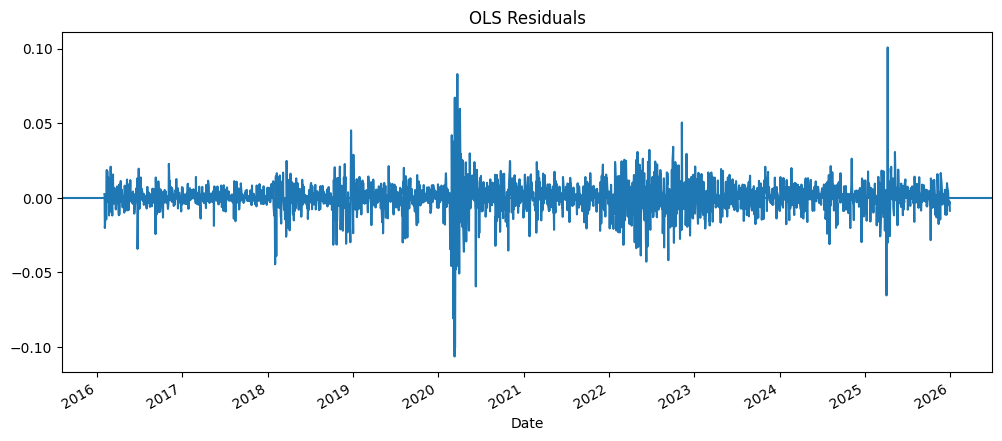

In [15]:
residuals.plot(
    figsize=(12, 5),
    title="OLS Residuals"
)

plt.axhline(0)
plt.show()

In [16]:
residuals.mean()

np.float64(2.1654470345927893e-18)

residual autocorrelation

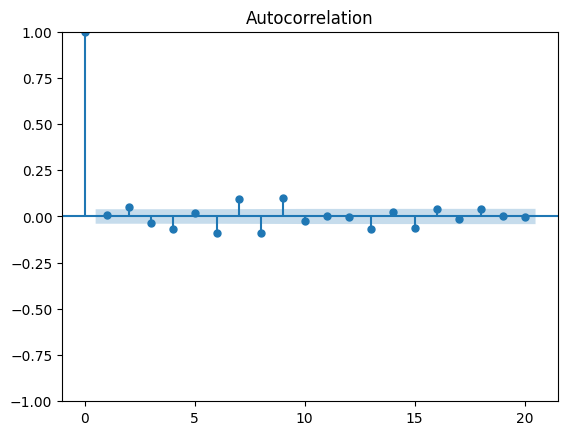

In [17]:
plot_acf(
    residuals,
    lags=20
)

plt.show()

Part 6：ADF stationarity test

In [19]:
def run_adf(series, name):
    result = adfuller(series.dropna())

    print(f"ADF Test: {name}")
    print(f"ADF statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")

    print("Critical values:")

    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")

In [21]:
run_adf(
    processed_data['ret_1d'],
    "SPY Price"
)

ADF Test: SPY Price
ADF statistic: -16.1829
p-value: 0.0000
Critical values:
  1%: -3.4330
  5%: -2.8627
  10%: -2.5674


In [22]:
run_adf(
    processed_data["ma_20_dist"],
    "20-Day MA Distance"
)

ADF Test: 20-Day MA Distance
ADF statistic: -11.8399
p-value: 0.0000
Critical values:
  1%: -3.4330
  5%: -2.8627
  10%: -2.5674


Part 7：ACF

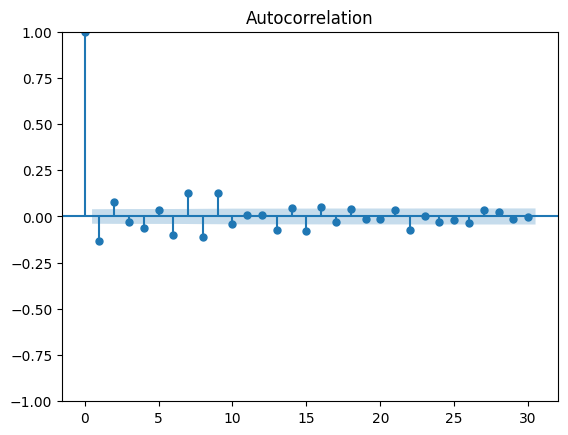

In [23]:
plot_acf(
    processed_data["ret_1d"],
    lags=30
)

plt.show()

In [24]:
ret = processed_data["ret_1d"]

lag1_corr = ret.corr(
    ret.shift(1)
)

lag1_corr

np.float64(-0.1343679939943448)

Part 8：squared returns ACF

In [25]:
processed_data["ret_sq"] = (
    processed_data["ret_1d"] ** 2
)

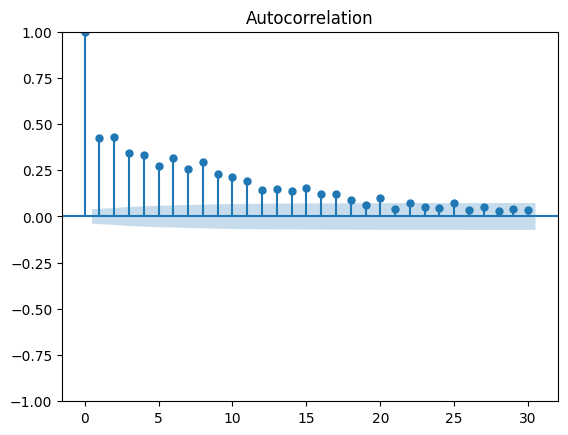

In [26]:
plot_acf(
    processed_data["ret_sq"],
    lags=30
)

plt.show()

volatility clustering

Part 9：PACF

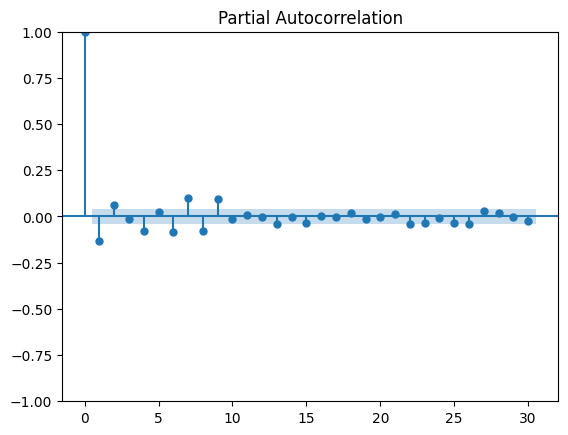

In [27]:
plot_pacf(
    processed_data["ret_1d"],
    lags=30,
    method="ywm"
)

plt.show()

ACF = total correlation

PACF = correlation after controlling intermediate lags

Part 10：Simple AR model

In [29]:
from statsmodels.tsa.ar_model import AutoReg

ar1 = AutoReg(
    processed_data["ret_1d"],
    lags=1,
    old_names=False
).fit()

print(ar1.summary())

                            AutoReg Model Results                             
Dep. Variable:                 ret_1d   No. Observations:                 2493
Model:                     AutoReg(1)   Log Likelihood                7656.208
Method:               Conditional MLE   S.D. of innovations              0.011
Date:                Mon, 14 Sep 2026   AIC                         -15306.416
Time:                        19:50:53   BIC                         -15288.954
Sample:                             1   HQIC                        -15300.076
                                 2493                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.000      3.255      0.001       0.000       0.001
ret_1d.L1     -0.1343      0.020     -6.769      0.000      -0.173      -0.095
                                    Roots           

/Users/yi/opt/anaconda3/envs/quant_1/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
